[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/joshuacaplan/tsr-labs/blob/main/Lab1_Evasion_Patch_Attack.ipynb)

# Lab 1 — Physical Evasion Attack: stickers that turn a STOP sign into a speed limit

**Threat model.** The attacker **cannot touch the model, its weights, or its training data** — they can only put a few **stickers on a real sign**. We show that a handful of black-and-white stickers make an *honest*, pretrained traffic-sign classifier read a **STOP sign as a "Speed limit 30 km/h" sign** — the autonomous-vehicle nightmare (a car that drives through a stop).

This is the attack of Eykholt et al., *Robust Physical-World Attacks on Deep Learning Visual Classification* (CVPR 2018) — the famous "stickers on a stop sign."

> **Real vs. simulated.** The sign is a *real photograph* of a real stop sign. The stickers are **applied digitally** and then optimised to survive **200+ random rotations / scales / lighting changes** — the standard proxy for "would still work once printed and seen through a camera." So this is a faithful **digital simulation** of the physical attack, not a printed sticker we re-photographed.

**Roadmap**
1. Load the honest victim model; confirm it reads a real STOP sign correctly.
2. A quick **digital** attack — and why it is *not* physically realistic.
3. The **physical sticker** attack (pre-computed): a crisp, high-resolution sign wearing printed stickers.
4. Show the misclassification, then prove it is **robust** to viewing conditions.
5. Defenses and AV implications.

> All lab code lives **outside** the research repo (which stays read-only). The heavy optimisation is pre-computed by `precompute_lab1.py`; this notebook just **loads** the result, so every cell runs in seconds.
>
> **Running on Colab?** Just do **Runtime ▸ Run all**. The next cell fetches everything automatically (no setup, no GPU needed).

In [ ]:
# === Colab bootstrap (automatically a no-op when you run locally) ===========
# On Colab this clones the public research repo (model weights, sample sign,
# utils/models) + this lab's repo (lab_common + pre-computed artifacts), so the
# rest of the notebook "just works". Running locally? This cell does nothing.
import os, sys
if "google.colab" in sys.modules:
    os.chdir("/content")
    if not os.path.exists("attacks-on-traffic-sign-recognition"):
        !git clone -q --depth 1 https://github.com/KASTEL-MobilityLab/attacks-on-traffic-sign-recognition
    if not os.path.exists("tsr-labs"):
        !git clone -q --depth 1 https://github.com/joshuacaplan/tsr-labs
    os.chdir("/content/tsr-labs")
    sys.path.insert(0, "/content/tsr-labs")
    print("Colab setup complete — running from", os.getcwd())
else:
    print("Local run — no bootstrap needed.")

## §0 · Setup

In [2]:
# grid_sample's backward is unimplemented on Apple MPS, so enable the CPU
# fallback for that one kernel BEFORE torch is imported.
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
import sys
sys.dont_write_bytecode = True            # keep the cloned repo pristine (no __pycache__)

%matplotlib inline
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import lab_common as lc                    # our helpers (live OUTSIDE the read-only repo)
import utils                               # the research repo's utilities (read-only)

device = lc.pick_device()
ART = os.path.join(lc.ARTIFACT_DIR, "lab1_sticker_CNNsmallGTSRB")
assert os.path.exists(os.path.join(ART, "adv_highres.png")), \
    "Artifacts missing — run:  PYTORCH_ENABLE_MPS_FALLBACK=1 python precompute_lab1.py"
print(f"PyTorch {torch.__version__}  |  device: {device}")

PyTorch 2.12.0  |  device: mps


## §1 · The victim model

In [3]:
# CNN-small (LISA-CNN), pretrained on GTSRB (43 classes, ~98% clean accuracy).
# A NORMAL, honest model — nothing about it is compromised. It returns raw
# logits (so softmax confidences are valid) and its input is 32x32.
params = lc.lab1_patch_params(ART, device=device)
model = utils.load_model(params)
labels = params["LABELS"]
CLEAN_CLASS, TARGET_CLASS = 14, 1          # Stop  ->  Speed limit 30 km/h
model.eval()

def model_view(highres, size=32):
    # What the 32x32 classifier actually ingests after the detected sign crop is
    # resized down: a differentiable bilinear downsample of the high-res image.
    return F.interpolate(highres.unsqueeze(0), size=(size, size),
                         mode="bilinear", align_corners=False)[0]

def predict_highres(highres):
    return lc.predict_one(model, model_view(highres), device)

print(f"Loaded CNN-small  |  attack target: {TARGET_CLASS}:{labels[TARGET_CLASS]}")

Loaded CNN-small  |  attack target: 1:1: Speed limit 30km/h


## §2 · Baseline — the real STOP sign (high-res)

A sanity check on a high-resolution stop sign. Note the two panels: the **left** is what *we* see (a crisp 256×256 image); the **right** is the tiny **32×32** crop the classifier actually ingests — every real in-car sign classifier downsamples the camera crop like this. That 32×32 is *where the pixelation lives* — not in our display.

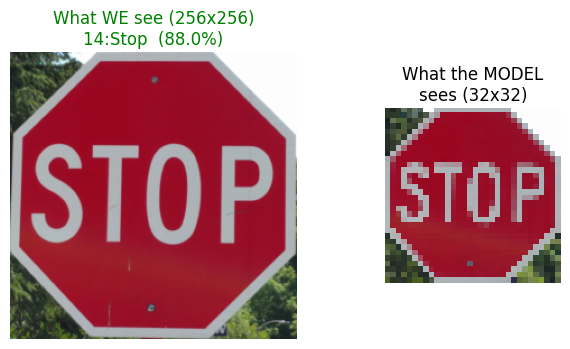

Clean sign -> 14:14:Stop @ 88.0%   (Speed-limit-30 conf: 0.59%)


In [4]:
clean = lc.load_highres_sign(os.path.join(ART, "clean_highres.png"), work_size=256)
idx, conf, probs = predict_highres(clean)

fig, ax = plt.subplots(1, 2, figsize=(7, 3.6), gridspec_kw={"width_ratios": [3, 1]})
ax[0].imshow(clean.permute(1, 2, 0)); ax[0].axis("off")
ax[0].set_title(f"What WE see (256x256)\n{labels[idx]}  ({conf*100:.1f}%)", color="green")
ax[1].imshow(model_view(clean).permute(1, 2, 0), interpolation="nearest"); ax[1].axis("off")
ax[1].set_title("What the MODEL\nsees (32x32)")
plt.tight_layout(); plt.show()

print(f"Clean sign -> {idx}:{labels[idx]} @ {conf*100:.1f}%   "
      f"(Speed-limit-30 conf: {probs[TARGET_CLASS]*100:.2f}%)")

## §3 · A *digital* attack first — and why it doesn't (yet) scare us

Neural classifiers are famously fragile: nudging the input pixels by an amount **too small to see** can flip the prediction. Below we do exactly that to the 32×32 the model ingests.

But there is a catch: a digital attack assumes the attacker can hand the model **exact pixel values**. Against a real car with a camera you cannot — the sign is photographed, cropped, resized, re-lit. **A realistic attack must live in the physical world.** That is the next section.

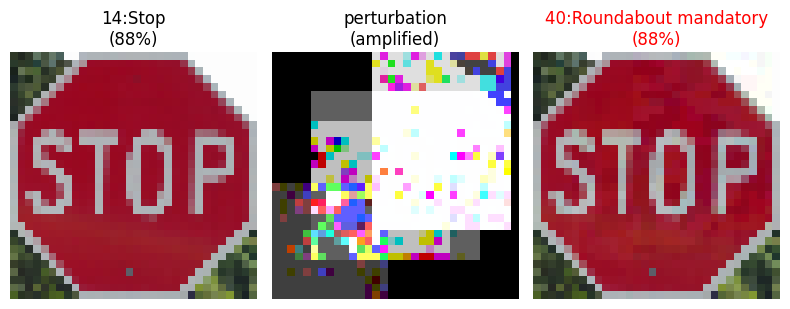

Digital PGD: 14:Stop -> 40:Roundabout mandatory  |  max pixel change 0.030 (~8/255)


In [5]:
# Untargeted PGD on the 32x32 model view (L-inf, eps=0.03 ~ 8 grey levels).
small = model_view(clean).clamp(0, 1)
adv_small = lc.pgd(model, small, label=CLEAN_CLASS, targeted=False,
                   eps=0.03, alpha=0.03/8, steps=30, device=device)
i0, c0, _ = lc.predict_one(model, small, device)
i1, c1, _ = lc.predict_one(model, adv_small, device)
diff = (adv_small - small).abs()

fig, ax = plt.subplots(1, 3, figsize=(8, 3))
for a in ax: a.axis("off")
ax[0].imshow(small.permute(1,2,0), interpolation="nearest");           ax[0].set_title(f"{labels[i0]}\n({c0*100:.0f}%)")
ax[1].imshow((diff/diff.max()).permute(1,2,0), interpolation="nearest"); ax[1].set_title("perturbation\n(amplified)")
ax[2].imshow(adv_small.permute(1,2,0), interpolation="nearest");        ax[2].set_title(f"{labels[i1]}\n({c1*100:.0f}%)", color="red")
plt.tight_layout(); plt.show()
print(f"Digital PGD: {labels[i0]} -> {labels[i1]}  |  max pixel change {diff.max():.3f} (~{diff.max()*255:.0f}/255)")

## §4 · The physical sticker attack

Now the realistic threat. We may change pixels **only inside a few sticker-shaped regions** on the sign face — a *mask* (the RP2 method of Eykholt et al.). To survive real-world viewing, the stickers are optimised under **Expectation-over-Transformation**: at every step the sign is randomly **rotated, scaled, and re-lit**, so the pattern must fool the model across many conditions, not just one.

The stickers are constrained to be **black-and-white** and optimised on a **crisp 256×256 image** that is then **downsampled to the model's 32×32 input** — exactly the camera→classifier pipeline of a real car.

This needs ~1500 gradient steps, so we ran it once offline (`precompute_lab1.py`) and just load the artifacts below. (Reminder: the stickers are applied digitally — see the note at the top.)

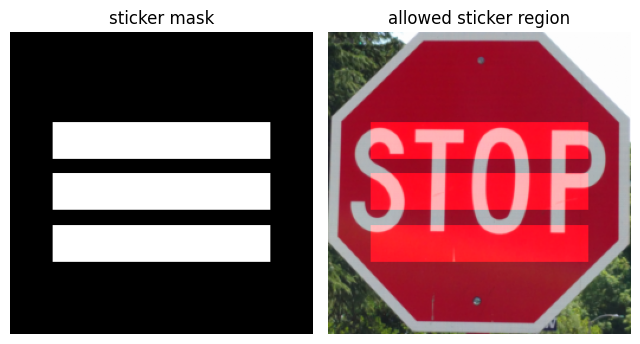

Stickers may cover only 26.1% of the image (black-and-white bands over 'STOP').


In [6]:
# Where the stickers are allowed to go (the RP2 mask).
mask = lc.load_highres_sign(os.path.join(ART, "mask.png"), work_size=256)[:1]  # 1 channel
overlay = clean.clone()
overlay[0] = torch.clamp(overlay[0] + 0.6 * mask[0], 0, 1)   # tint masked region red

fig, ax = plt.subplots(1, 2, figsize=(6.5, 3.4))
for a in ax: a.axis("off")
ax[0].imshow(mask[0], cmap="gray");           ax[0].set_title("sticker mask")
ax[1].imshow(overlay.permute(1, 2, 0));       ax[1].set_title("allowed sticker region")
plt.tight_layout(); plt.show()
print(f"Stickers may cover only {float(mask.mean())*100:.1f}% of the image "
      f"(black-and-white bands over 'STOP').")

## §5 · The result: same physical sign, wrong classification

Here is the result, side by side. Left: the real sign. Right: the *same* sign wearing the (digitally-applied) black-and-white stickers. The model — **unchanged** — now reads it as a speed limit. The bottom row is what the classifier actually ingests in each case.

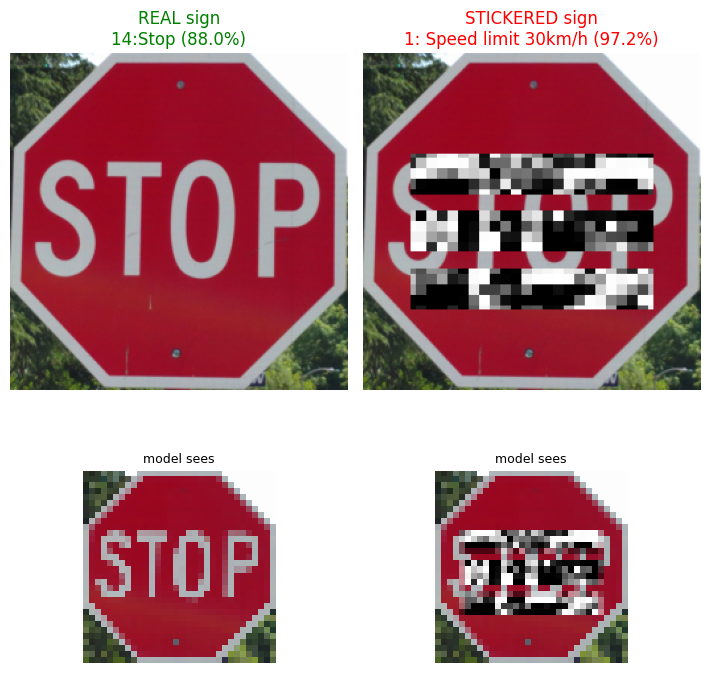

Attack succeeded: the stickered STOP sign is read as 1: Speed limit 30km/h @ 97.2%.


In [7]:
adv = lc.load_highres_sign(os.path.join(ART, "adv_highres.png"), work_size=256)
i_c, c_c, _   = predict_highres(clean)
i_a, c_a, p_a = predict_highres(adv)

fig, ax = plt.subplots(2, 2, figsize=(7.2, 7.6), gridspec_kw={"height_ratios": [3, 1]})
for a in ax.ravel(): a.axis("off")
ax[0,0].imshow(clean.permute(1,2,0)); ax[0,0].set_title(f"REAL sign\n{labels[i_c]} ({c_c*100:.1f}%)", color="green")
ax[0,1].imshow(adv.permute(1,2,0));   ax[0,1].set_title(f"STICKERED sign\n{labels[i_a]} ({c_a*100:.1f}%)", color="red")
ax[1,0].imshow(model_view(clean).permute(1,2,0), interpolation="nearest"); ax[1,0].set_title("model sees", fontsize=9)
ax[1,1].imshow(model_view(adv).permute(1,2,0),   interpolation="nearest"); ax[1,1].set_title("model sees", fontsize=9)
plt.tight_layout(); plt.show()

assert i_a == TARGET_CLASS, "the stickered sign did not reach the target class"
print(f"Attack succeeded: the stickered STOP sign is read as {labels[i_a]} @ {c_a*100:.1f}%.")

## §6 · Physical robustness (Expectation-over-Transformation)

A real camera never sees the sign perfectly head-on under fixed light. We re-test the stickered sign under **200 random rotations / scales / brightness / contrast** changes. A high percentage here is what separates a *physical* attack from a fragile digital one.

100.0% of 200 random augmented views are STILL read as 1: Speed limit 30km/h.



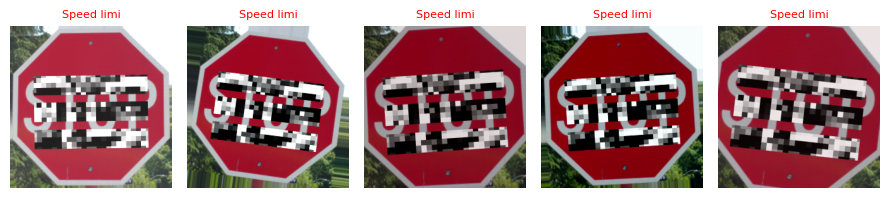

In [8]:
rob = lc.robustness_under_augmentation(model, adv, TARGET_CLASS, device, n=200)
print(f"{rob*100:.1f}% of 200 random augmented views are STILL read as {labels[TARGET_CLASS]}.\n")

# A few of those augmented views (exactly what the classifier is fed):
g = torch.Generator(device="cpu").manual_seed(7)
views = lc._eot_views(adv.unsqueeze(0).expand(5, -1, -1, -1).to(device),
                      12.0, (0.85, 1.15), 0.15, 0.15, g, device)
preds = model(F.interpolate(views, size=(32, 32), mode="bilinear", align_corners=False)).argmax(1).cpu()
fig, ax = plt.subplots(1, 5, figsize=(9, 2))
for k in range(5):
    ax[k].imshow(views[k].cpu().permute(1, 2, 0)); ax[k].axis("off")
    ax[k].set_title(labels[int(preds[k])].split(":")[-1].strip()[:10], fontsize=8, color="red")
plt.tight_layout(); plt.show()

## §7 · Why it matters, and what defends against it

**Safety.** A STOP sign read as a speed limit means a car that **does not stop**. Evasion attacks like this target the *input* of an otherwise-perfect model — no system bug, no bad training, just physics and gradients.

**Defenses (none is a silver bullet):**
- **Adversarial training** — train on perturbed examples (costly; narrows but doesn't close the gap).
- **Input transforms / denoising**, randomized smoothing.
- **Sensor fusion + temporal consistency** — a real sign doesn't flicker between classes across frames; lidar / HD-maps disagree with a "speed limit" octagon.
- **Patch / anomaly detectors** that flag unusual high-saliency regions on a sign face.

**Bridge to Lab 2.** Here the model was *honest* and we attacked its **input**. In Lab 2 we do the opposite — **poison the training data** so the model itself carries a hidden backdoor.

## §8 · (optional) Run the attack live

In [9]:
RUN_LIVE = False   # set True to optimise a fresh patch live (~30 s on MPS)
if RUN_LIVE:
    base = lc.load_highres_sign(os.path.join(lc.ATTACK_UTILS_DIR, "stop_sign.png"), 256)
    m = lc.build_sticker_mask(256, [(0.14, 0.30, 0.86, 0.42),
                                    (0.14, 0.47, 0.86, 0.59),
                                    (0.14, 0.64, 0.86, 0.76)])
    _, live_adv, (li, lconf, _) = lc.optimize_sticker_patch(
        model, base, m, TARGET_CLASS, device, epochs=600, lr=0.05,
        eot_samples=8, tile=8, grayscale=True, seed=0, log_every=100)
    plt.imshow(live_adv.permute(1, 2, 0)); plt.axis("off")
    plt.title(f"live: {labels[li]} ({lconf*100:.1f}%)", color="red"); plt.show()
else:
    print("RUN_LIVE is False — using the pre-computed artifact.")

RUN_LIVE is False — using the pre-computed artifact.
